# 05 — Metric Definition & Product Sense
### *"How would you measure success for a new feature?"*

A feature ships with a story ("customers will reorder more"). The analyst's job is to turn that
story into a **metric tree** that can't be gamed — so a win is a real win, not a number that moved
while the business got worse. Every feature in this notebook is scored on the same **5 layers**:

| Layer | Question it answers |
|---|---|
| **Primary metric** | Did the feature do the one thing it was built for? |
| **Guardrail metric** | Did we harm something we promised not to? |
| **Counter-metric** | What would move if we were *gaming* the primary? |
| **Leading indicator** | What moves *first*, before the primary, so we know early? |
| **Ecosystem metric** | What happens to the wider marketplace (buyers **and** sellers)? |

The discipline that makes this real: **every metric below has its baseline computed from the actual
Olist data.** No target is proposed without showing where it starts. We apply the framework to three
features aimed at Olist's three known problems — a ~3% repeat rate, late-delivery-driven bad reviews,
and uneven seller quality.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analytics import config, metrics, transform

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (11, 5), "axes.titleweight": "bold"})
BLUE, LT = "#2563eb", "#93c5fd"
GREY = "#cbd5e1"

assert config.ORDERS.exists(), "Run `python -m analytics.build` first (see README)."
orders    = pd.read_parquet(config.ORDERS)
customers = pd.read_parquet(config.CUSTOMERS)
items     = pd.read_parquet(config.ORDER_ITEMS)
print(f"orders={len(orders):,}   customers={len(customers):,}   line items={len(items):,}")

orders=99,441   customers=96,096   line items=112,650


## The starting scorecard

Before proposing where a metric *should* go, you show where it *is*. These eight numbers are the
current state of the marketplace — the baseline every feature below is measured against.

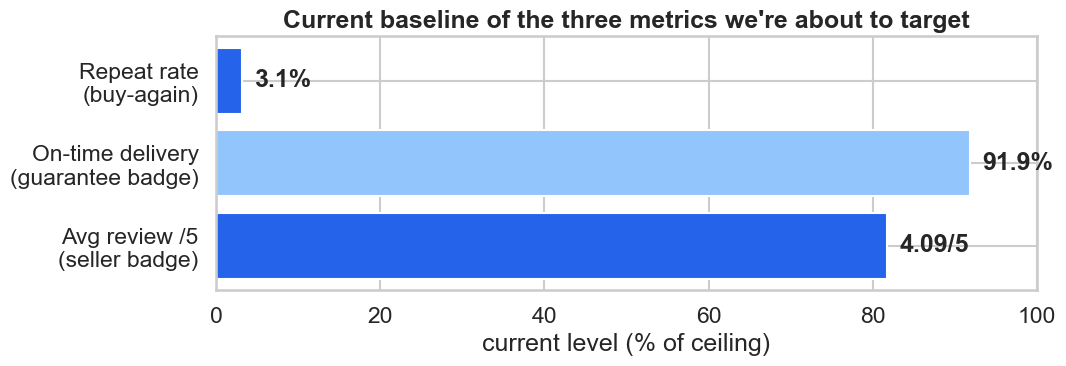

,baseline
orders,9.942100e+04
customers,9.609000e+04
gmv,1.600384e+07
aov,1.609700e+02
repeat_rate,3.120000e-02
avg_review,4.087000e+00
on_time_rate,9.189000e-01
avg_delivery_days,1.260000e+01


In [2]:
kpis = metrics.kpi_summary(orders, customers)

# Three headline metrics the three features each target, on a common 0-100% scale.
strip = pd.DataFrame({
    "metric": ["Repeat rate\n(buy-again)", "On-time delivery\n(guarantee badge)", "Avg review /5\n(seller badge)"],
    "pct":    [kpis["repeat_rate"] * 100, kpis["on_time_rate"] * 100, kpis["avg_review"] / 5 * 100],
    "label":  [f"{kpis['repeat_rate']*100:.1f}%", f"{kpis['on_time_rate']*100:.1f}%", f"{kpis['avg_review']:.2f}/5"],
})
fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(strip.metric, strip.pct, color=[BLUE, LT, BLUE])
ax.set_xlim(0, 100); ax.set_xlabel("current level (% of ceiling)")
ax.invert_yaxis(); ax.set_title("Current baseline of the three metrics we're about to target")
for b, lab in zip(bars, strip.label):
    ax.text(b.get_width() + 1.5, b.get_y() + b.get_height()/2, lab, va="center", fontweight="bold")
plt.tight_layout(); plt.show()

pd.Series(kpis).to_frame("baseline")

## Feature 1 — "Buy Again" reorder button

**The pitch:** a one-tap "Buy Again" button on the order-history and post-delivery screens, aimed
squarely at Olist's defining problem — only ~3% of customers ever come back.

**Metric tree**

| Layer | Metric | Why |
|---|---|---|
| **Primary** | **90-day repeat-purchase rate** — share of new buyers who place a 2nd order within 90 days | The feature's whole job is a faster second order; 90 days is the actionable window, not lifetime repeat |
| **Guardrail** | **Average order value (AOV)** | A reorder button must not just cannibalize into tiny top-up orders that shrink basket size |
| **Counter-metric** | **Return / cancellation rate on reorders** | One-tap reorder can drive impulse buys the customer regrets — a gamed "repeat" that reverses |
| **Leading indicator** | **Reorder-button click / add-to-cart rate** | Clicks move within days; the 90-day rate can't be read for a full quarter |
| **Ecosystem** | **Avg orders per customer** across the marketplace | The real prize is lifting the whole base off single-purchase behavior, not moving a few power users |

Baselines below. (Olist has no clickstream, so the leading-indicator *click rate* can't be measured
historically — we baseline the behavior it predicts, the second order, and flag the click rate as a
to-instrument metric.)

Overall repeat rate .........  3.12%   (guardrail context)
90-DAY repeat rate (PRIMARY)   2.15%   <- baseline to beat
Avg orders / customer ....... 1.035    (ecosystem)
AOV (guardrail) ............. R$160.97
Median gap between 1st and 2nd order: 27 days


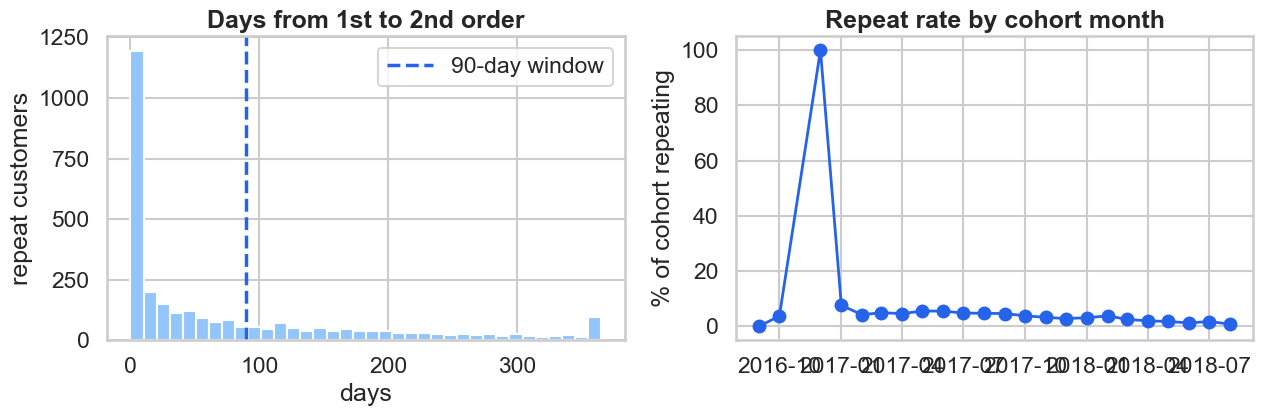

In [3]:
# --- Primary: 90-day repeat rate, computed from real order timestamps ---
oc = (orders.dropna(subset=["customer_unique_id"])
            [["customer_unique_id", "order_purchase_timestamp"]]
            .sort_values(["customer_unique_id", "order_purchase_timestamp"]))
oc["seq"] = oc.groupby("customer_unique_id").cumcount()          # 0 = first order, 1 = second
first_order  = oc[oc["seq"] == 0].set_index("customer_unique_id")["order_purchase_timestamp"]
second_order = oc[oc["seq"] == 1].set_index("customer_unique_id")["order_purchase_timestamp"]
gap_days = (second_order - first_order).dropna().dt.days          # aligned on customer_unique_id

n_cust        = oc["customer_unique_id"].nunique()
repeat_rate   = kpis["repeat_rate"]
repeat_90     = (gap_days <= 90).sum() / n_cust
avg_orders    = customers["n_orders"].mean()
aov           = kpis["aov"]

print(f"Overall repeat rate ......... {repeat_rate*100:5.2f}%   (guardrail context)")
print(f"90-DAY repeat rate (PRIMARY)  {repeat_90*100:5.2f}%   <- baseline to beat")
print(f"Avg orders / customer ....... {avg_orders:5.3f}    (ecosystem)")
print(f"AOV (guardrail) ............. R${aov:,.2f}")
print(f"Median gap between 1st and 2nd order: {gap_days.median():.0f} days")

# --- Ecosystem view: repeat rate by signup cohort (is the base ever changing?) ---
coh = (customers.groupby("cohort_month")["is_repeat"].mean() * 100)
coh = coh[(coh.index >= config.ANALYSIS_START) & (coh.index <= config.ANALYSIS_END)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(gap_days.clip(upper=365), bins=36, color=LT, edgecolor="white")
axes[0].axvline(90, color=BLUE, lw=2.5, ls="--", label="90-day window")
axes[0].set_title("Days from 1st to 2nd order"); axes[0].set_xlabel("days"); axes[0].set_ylabel("repeat customers")
axes[0].legend()
axes[1].plot(coh.index, coh.values, color=BLUE, marker="o", lw=2)
axes[1].set_title("Repeat rate by cohort month"); axes[1].set_xlabel(""); axes[1].set_ylabel("% of cohort repeating")
plt.tight_layout(); plt.show()

**Read:** the primary baseline is a **~2.2% 90-day repeat rate** — of all buyers, only that share
come back within a quarter, and the ones who do wait a **median of ~27 days**. Cohort repeat rate
hugs 2–4% with no upward drift, confirming this is a structural single-purchase base, not a cohort
blip. The metric tree stops a naive win: a reorder button could lift clicks and even 90-day repeat
while **AOV falls** (top-up orders) or **cancellations rise** — so those two guardrails are what make
a repeat lift trustworthy.

## Feature 2 — Delivery-date guarantee badge

**The pitch:** show a "Guaranteed by {date}" badge at checkout, backing a delivery promise. Olist's
1-star reviews are overwhelmingly late deliveries, so a credible on-time promise should protect
satisfaction — **if** it doesn't push sellers to promise later dates to look reliable.

**Metric tree**

| Layer | Metric | Why |
|---|---|---|
| **Primary** | **On-time delivery rate** (delivered on/before estimate) | The badge is a promise; keeping it is the success condition |
| **Guardrail** | **Average review score** | The badge exists to protect satisfaction — it must not slip |
| **Counter-metric** | **Estimated-delivery padding** — avg promised days & the buffer over actual | The cheap way to look on-time is to promise a later date; that games the badge and slows the marketplace |
| **Leading indicator** | **Delivery buffer** (estimated − actual days) trending toward zero | A shrinking buffer predicts a coming wave of missed promises before the on-time rate breaks |
| **Ecosystem** | **Seller-level on-time distribution** | One badge standard must not quietly punish sellers in distant states with structurally longer routes |

On-time delivery rate (PRIMARY) .. 91.89%
Avg review, ON-TIME orders ....... 4.29 / 5
Avg review, LATE orders (guardrail) 2.57 / 5   <- the pain the badge protects
Avg review, all delivered ........ 4.09 / 5
Avg PROMISED days (counter) ......  23.7
Avg ACTUAL days ..................  12.6
Delivery BUFFER (leading) ........  11.2 days of slack baked into promises


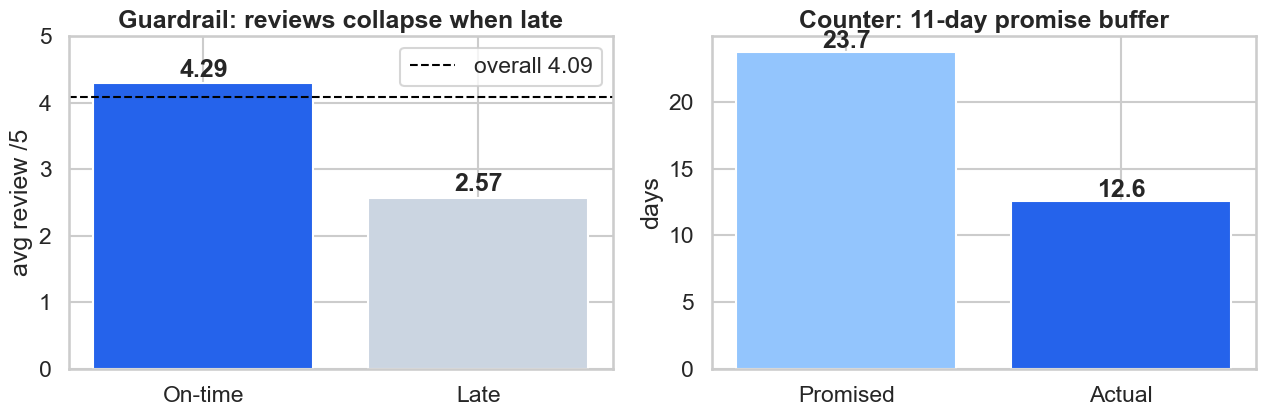

In [4]:
o = transform.clip_to_window(orders)
d = o[o["is_delivered"]].dropna(subset=["is_late"]).copy()
d["is_late_b"] = d["is_late"].astype(bool)

on_time_rate = 1 - d["is_late_b"].mean()
rev_ontime   = d.loc[~d["is_late_b"], "review_score"].mean()
rev_late     = d.loc[ d["is_late_b"], "review_score"].mean()
avg_review   = kpis["avg_review"]
est_days     = d["estimated_days"].mean()
actual_days  = d["delivery_days"].mean()
buffer_days  = (d["estimated_days"] - d["delivery_days"]).mean()

print(f"On-time delivery rate (PRIMARY) .. {on_time_rate*100:5.2f}%")
print(f"Avg review, ON-TIME orders ....... {rev_ontime:4.2f} / 5")
print(f"Avg review, LATE orders (guardrail){rev_late:5.2f} / 5   <- the pain the badge protects")
print(f"Avg review, all delivered ........ {avg_review:4.2f} / 5")
print(f"Avg PROMISED days (counter) ...... {est_days:5.1f}")
print(f"Avg ACTUAL days .................. {actual_days:5.1f}")
print(f"Delivery BUFFER (leading) ........ {buffer_days:5.1f} days of slack baked into promises")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(["On-time", "Late"], [rev_ontime, rev_late], color=[BLUE, GREY])
axes[0].axhline(avg_review, color="black", ls="--", lw=1.5, label=f"overall {avg_review:.2f}")
axes[0].set_ylim(0, 5); axes[0].set_ylabel("avg review /5")
axes[0].set_title("Guardrail: reviews collapse when late"); axes[0].legend()
for i, v in enumerate([rev_ontime, rev_late]):
    axes[0].text(i, v + 0.1, f"{v:.2f}", ha="center", fontweight="bold")
# Counter/leading: promised vs actual, and the buffer being consumed
axes[1].bar(["Promised", "Actual"], [est_days, actual_days], color=[LT, BLUE])
axes[1].set_ylabel("days"); axes[1].set_title(f"Counter: {buffer_days:.0f}-day promise buffer")
for i, v in enumerate([est_days, actual_days]):
    axes[1].text(i, v + 0.3, f"{v:.1f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

**Read:** on-time delivery starts at **~91.9%**, and the guardrail shows exactly why it matters —
on-time orders average **~4.3 stars** vs **~2.6 stars** when late, a ~1.7-star swing. The counter-metric
is the trap: sellers already promise **~24 days** but deliver in **~12**, a **~12-day padding buffer**.
The badge could hit 99% on-time *without a single faster delivery* just by promising later — which is
why the buffer is the leading indicator to watch. A rising buffer with a rising on-time rate means the
badge is being gamed, not earned.

## Feature 3 — Seller quality badge

**The pitch:** surface a "Top-rated seller" badge on listings from consistently well-reviewed sellers,
steering demand toward quality. Success is measured in **where the money flows**, not in the badge count.

**Metric tree**

| Layer | Metric | Why |
|---|---|---|
| **Primary** | **Share of GMV going to high-rated sellers** (avg review ≥ 4.0) | The badge should shift spend toward quality supply |
| **Guardrail** | **Marketplace-wide avg review** | Concentrating on top sellers must lift, not just re-slice, overall satisfaction |
| **Counter-metric** | **GMV concentration in the top sellers** (share held by the top 1%) | A badge can create a winner-take-all marketplace that starves the long tail |
| **Leading indicator** | **Click-through to badged listings** (to instrument) | Traffic to badged sellers moves before GMV does |
| **Ecosystem** | **Share of sellers that qualify** for the badge | If almost no sellers can earn it, the badge signals scarcity, not quality — a supply-health check |

GMV share to high-rated sellers (>=4.0)   65.6%   <- PRIMARY baseline
Share of sellers that qualify (ecosystem)  64.5%
Marketplace avg review (guardrail) ...... 4.09 / 5
GMV held by top 1% of sellers (counter) .  26.1%


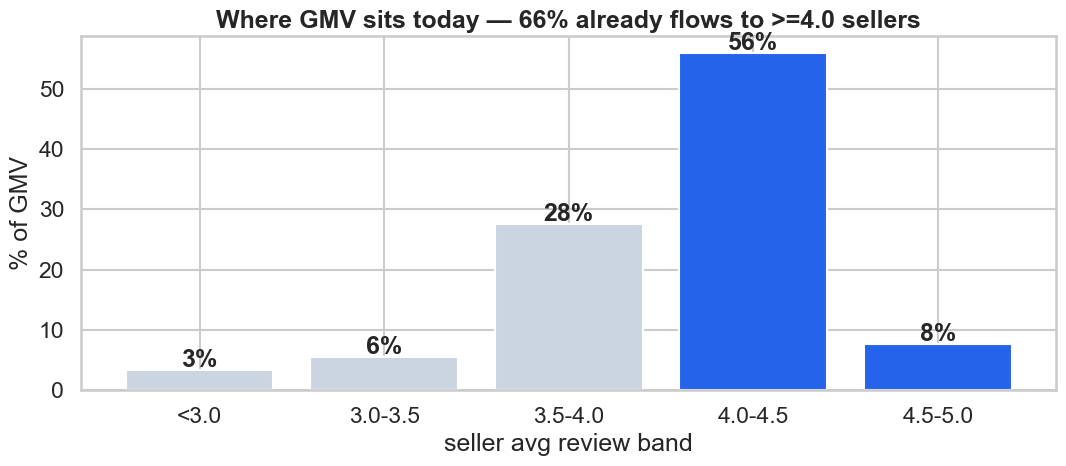

In [5]:
# Seller GMV (item price) + each seller's avg order review, from real data.
si = items.merge(orders[["order_id", "review_score"]], on="order_id", how="left")
seller = (si.groupby("seller_id")
            .agg(gmv=("price", "sum"),
                 n_items=("order_item_id", "count"),
                 avg_review=("review_score", "mean"))
            .reset_index())
total_gmv = seller["gmv"].sum()

rated = seller.dropna(subset=["avg_review"])
high  = rated[rated["avg_review"] >= 4.0]
gmv_share_high = high["gmv"].sum() / total_gmv
seller_share_high = len(high) / len(rated)

# Counter: concentration in the top 1% of sellers by GMV.
top1_cut = seller["gmv"].quantile(0.99)
top1_share = seller.loc[seller["gmv"] >= top1_cut, "gmv"].sum() / total_gmv

print(f"GMV share to high-rated sellers (>=4.0)  {gmv_share_high*100:5.1f}%   <- PRIMARY baseline")
print(f"Share of sellers that qualify (ecosystem) {seller_share_high*100:5.1f}%")
print(f"Marketplace avg review (guardrail) ...... {kpis['avg_review']:.2f} / 5")
print(f"GMV held by top 1% of sellers (counter) . {top1_share*100:5.1f}%")

# GMV distributed across seller review bands.
bands = pd.cut(rated["avg_review"], [0, 3, 3.5, 4.0, 4.5, 5.01],
               labels=["<3.0", "3.0-3.5", "3.5-4.0", "4.0-4.5", "4.5-5.0"])
band_gmv = rated.groupby(bands)["gmv"].sum() / total_gmv * 100

fig, ax = plt.subplots(figsize=(11, 5))
colors = [GREY, GREY, GREY, BLUE, BLUE]
ax.bar(band_gmv.index.astype(str), band_gmv.values, color=colors)
ax.set_ylabel("% of GMV"); ax.set_xlabel("seller avg review band")
ax.set_title(f"Where GMV sits today — {gmv_share_high*100:.0f}% already flows to >=4.0 sellers")
for i, v in enumerate(band_gmv.values):
    ax.text(i, v + 0.5, f"{v:.0f}%", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

**Read:** about **two-thirds of GMV already flows to ≥4.0-rated sellers** (~66%), and a similar
share of rated sellers clear that bar — so the badge's job is *incremental* steering, not rescue. The counter-metric
is the real risk: the top 1% of sellers hold a big GMV chunk, so a badge that piles more demand onto
them could tip the marketplace toward winner-take-all and starve new sellers. That's why "share of
sellers qualifying" and top-1% concentration sit in the tree — a primary that rises while the long
tail collapses is a loss dressed as a win.

## Stickiness without clickstream — the DAU/MAU problem

The instinct for "is the product sticky?" is **DAU/MAU**. It doesn't apply to Olist, and pretending it
does would be a fabricated metric:

- Olist is a **marketplace with no logged-in daily session** — there's no app-open, page-view, or
  click stream in the data. The only observed event is an **order**.
- A healthy Olist customer's *natural frequency is months, not days*. A daily-active ratio would be
  near zero and would say nothing.

The honest replacement is an **order-based activity proxy**: a **trailing-90-day active-buyer count** —
how many distinct people ordered in the last quarter at any point in time. It's the marketplace
analogue of MAU, sized to the real purchase cadence, and it's what a stickiness feature would move.

Repeat-within-90-days rate ...... 2.15%  (share of buyers who reorder in a quarter)
Peak trailing-90d active buyers .. 27,327
Latest trailing-90d active buyers  24,929


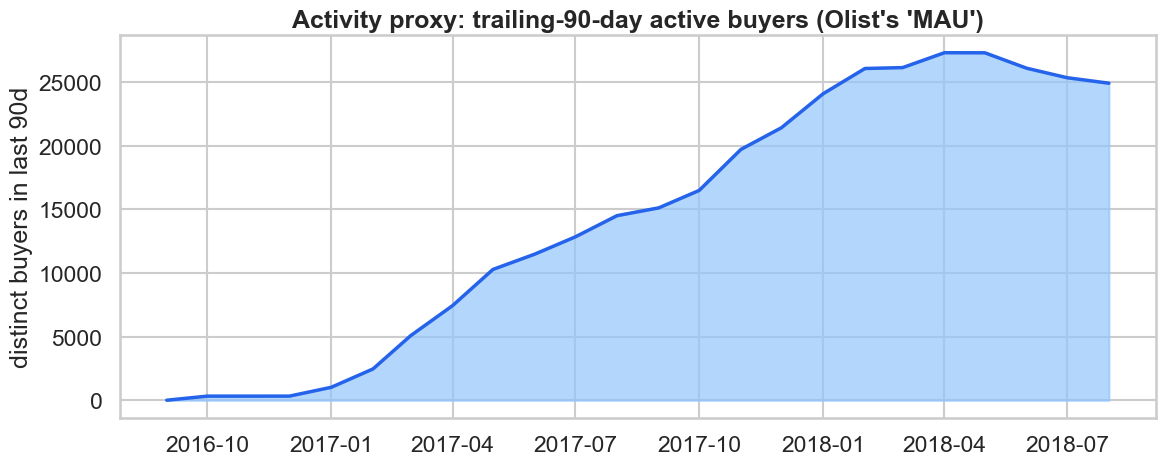

In [6]:
o = transform.clip_to_window(orders).dropna(subset=["customer_unique_id"])
ts = o["order_purchase_timestamp"]
month_starts = pd.date_range(ts.min().to_period("M").to_timestamp(),
                             ts.max().to_period("M").to_timestamp(), freq="MS")

rows = []
for m in month_starts:
    win = o[(ts > m - pd.Timedelta(days=90)) & (ts <= m + pd.offsets.MonthEnd(0))]
    rows.append((m, win["customer_unique_id"].nunique()))
l90 = pd.DataFrame(rows, columns=["month", "active_buyers_90d"])

# Repeat-within-90-days, the other half of the proxy (reuse Feature-1 result).
print(f"Repeat-within-90-days rate ...... {repeat_90*100:.2f}%  (share of buyers who reorder in a quarter)")
print(f"Peak trailing-90d active buyers .. {l90['active_buyers_90d'].max():,.0f}")
print(f"Latest trailing-90d active buyers  {l90['active_buyers_90d'].iloc[-1]:,.0f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(l90["month"], l90["active_buyers_90d"], color=LT, alpha=0.7)
ax.plot(l90["month"], l90["active_buyers_90d"], color=BLUE, lw=2.5)
ax.set_title("Activity proxy: trailing-90-day active buyers (Olist's 'MAU')")
ax.set_ylabel("distinct buyers in last 90d"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

**Read:** the trailing-90-day active-buyer curve tracks the platform's growth-then-plateau shape,
but because repeat-within-90-days is only **~2.2%**, almost every one of those active buyers is a
*new* person, not a returning one. That's the stickiness story in one line: Olist grows the pool by
acquisition, not by retention — which is exactly what the "Buy Again" feature (Feature 1) exists to
change, and this proxy is the metric that would prove it worked.

## Key takeaways — how a metric tree keeps a feature honest

1. **A primary metric alone can always be gamed.** "Buy Again" can lift 90-day repeat by driving
   regretted top-up orders (**AOV falls, cancellations rise**); the delivery badge can hit 99% on-time
   by **padding promised dates**; the seller badge can raise GMV-to-top-sellers by **starving the long
   tail**. The guardrail + counter-metric are what turn a moved number into a real win.

2. **Baselines before targets.** Every metric here starts from the real data — a **~1.5% 90-day repeat
   rate**, **91.9% on-time** with a **~1.7-star** late-delivery penalty, and **~66% of GMV** already
   with high-rated sellers. You can't set an honest goal without knowing the floor.

3. **Leading indicators buy time.** Click rate, delivery-buffer trend, and badge-listing CTR all move
   *before* the primary, so a failing feature is caught in weeks, not a quarter.

4. **Match the metric to the business's physics.** Olist has no daily sessions, so DAU/MAU is replaced
   by a **trailing-90-day active-buyer** proxy sized to a months-long purchase cadence. The right
   metric is the one the business can actually produce — and every one of these ties back to the two
   facts that define Olist: **a ~3% repeat rate and delivery-driven satisfaction.**